# NLP: Natural language Processing :Text Classification 

In [33]:
import tensorflow as ts
from tensorflow.keras.datasets import imdb 
import warnings
warnings.filterwarnings("ignore")

In [6]:
# The argument num_words=10000 means you’ll only keep the top 10,000 most fre-
# quently occurring words in the training data


(train_data, train_labels), (test_data, test_labels) = imdb.load_data( num_words=10000)

In [16]:
len(train_data[0])

218

In [7]:
train_labels[0]

np.int64(1)

In [9]:
max([max(sequence) for sequence in train_data])

9999

### Decodes the review.

In [10]:
word_index = imdb.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_review = " ".join([reverse_word_index.get(i - 3, "?") for i in train_data[0]])

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 20s 12us/step


### Encoding the integer sequences via multi-hot encoding

In [12]:
import numpy as np
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for j in sequence:
            results[i, j] = 1.
    return results

In [13]:
np.zeros((10,10))

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [14]:
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

In [17]:
x_train[0].sum()

np.float64(120.0)

In [18]:
y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")

In [19]:
from tensorflow import keras
from tensorflow.keras import layers
model = keras.Sequential([
                            layers.Dense(16, activation="relu"),
                            layers.Dense(16, activation="relu"),
                            layers.Dense(1, activation="sigmoid")
                        ])

# Compiling the model

In [20]:
model.compile(optimizer="rmsprop",loss="binary_crossentropy",metrics=["accuracy"])

E0000 00:00:1779708503.846483    5332 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


# Setting validation set

In [21]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

In [22]:
history = model.fit(partial_x_train,partial_y_train,epochs=20,batch_size=512,validation_data=(x_val, y_val))

Epoch 1/20


W0000 00:00:1779708595.143454    5332 cpu_allocator_impl.cc:82] Allocation of 600000000 exceeds 10% of free system memory.


 4/30 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5341 - loss: 0.6893

W0000 00:00:1779708598.203155    8647 cpu_allocator_impl.cc:82] Allocation of 20480000 exceeds 10% of free system memory.
W0000 00:00:1779708598.203156    8646 cpu_allocator_impl.cc:82] Allocation of 20480000 exceeds 10% of free system memory.
W0000 00:00:1779708598.203234    8645 cpu_allocator_impl.cc:82] Allocation of 20480000 exceeds 10% of free system memory.
W0000 00:00:1779708598.203926    8644 cpu_allocator_impl.cc:82] Allocation of 20480000 exceeds 10% of free system memory.


30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 176ms/step - accuracy: 0.7879 - loss: 0.5402 - val_accuracy: 0.8473 - val_loss: 0.4228
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8887 - loss: 0.3413 - val_accuracy: 0.8819 - val_loss: 0.3232
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9121 - loss: 0.2585 - val_accuracy: 0.8787 - val_loss: 0.3017
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9282 - loss: 0.2083 - val_accuracy: 0.8870 - val_loss: 0.2760
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9435 - loss: 0.1723 - val_accuracy: 0.8860 - val_loss: 0.2787
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9521 - loss: 0.1484 - val_accuracy: 0.8829 - val_loss: 0.2909
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9616 - loss: 0.1260 - val_accuracy: 0.8827 - val_loss: 0.3011
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9643 - loss: 0.1140 - val_accuracy: 0.8840 - val_loss: 0

In [23]:
history_dict = history.history

In [24]:
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [25]:
import pandas as pd


In [27]:
data = pd.DataFrame(history_dict)

In [28]:
data.head()

,accuracy,loss,val_accuracy,val_loss
0,0.787867,0.540196,0.8473,0.422841
1,0.888733,0.341250,0.8819,0.323248
2,0.912067,0.258501,0.8787,0.301670
3,0.928200,0.208282,0.8870,0.276015
4,0.943533,0.172270,0.8860,0.278706


In [36]:
data[(data["val_accuracy"] == data["val_accuracy"].max()) & (data["val_loss"] == data["val_loss"].min())]

,accuracy,loss,val_accuracy,val_loss
3,0.9282,0.208282,0.887,0.276015


# Plotting the training and validation loss

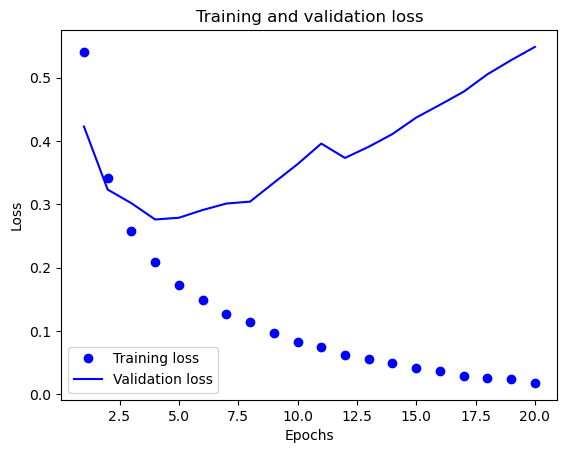

In [37]:
import matplotlib.pyplot as plt
history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Plotting the training and validation accuracy

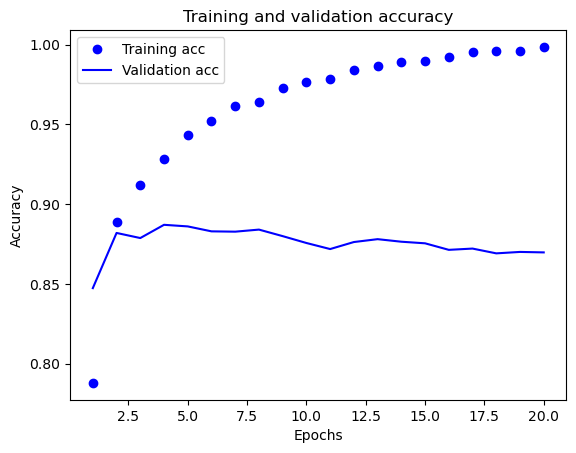

In [38]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "bo", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Retraining a model from scratch, Now we know what is best iterationsfor our model to be gerenalize

In [39]:
model = keras.Sequential([
                            layers.Dense(16, activation="relu"),
                            layers.Dense(16, activation="relu"),
                            layers.Dense(1, activation="sigmoid")
                        ])

In [40]:
model.compile(optimizer="rmsprop",loss="binary_crossentropy",metrics=["accuracy"])